# 1D Stock Cutting Optimiser

Minimise material cost by selecting which stock bars to cut, constrained by profile compatibility and length.

**Inputs** (edit the CSV cells below):
- **Available stock**: name, profile (`l1 x l2`), length (mm), cost per bar
- **Needed parts**: name, profile (`l1 x l2`), length (mm), quantity

**Solver**: Google OR-Tools CP-SAT

In [5]:
import io
import math
import textwrap
from itertools import cycle

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
from ortools.sat.python import cp_model

## 2 — Input Data (edit the CSV strings below)

Each stock entry: `name, profile_l1, profile_l2, length_mm, cost_per_bar`  
Each part entry: `name, profile_l1, profile_l2, length_mm, quantity`

Profile matching is exact: a part is only cut from stock with the same `l1 x l2`.

In [6]:
STOCK_CSV = """
name,profile_l1,profile_l2,length_mm,cost_per_bar
HEA200_6m,200,200,6000,42.50
HEA200_12m,200,200,12000,78.00
IPE300_6m,150,300,6000,55.00
IPE300_12m,150,300,12000,102.00
RHS100_6m,100,100,6000,28.00
"""

PARTS_CSV = """
name,profile_l1,profile_l2,length_mm,quantity
beam_A,200,200,2400,3
beam_B,200,200,1800,4
column_C,150,300,3200,2
column_D,150,300,900,5
brace_E,100,100,1100,6
brace_F,100,100,750,4
"""

## 3 — Parse & Validate Inputs

In [7]:
stocks = pd.read_csv(io.StringIO(STOCK_CSV.strip()))
parts  = pd.read_csv(io.StringIO(PARTS_CSV.strip()))

# Add a tuple key for profile matching
stocks["profile"] = list(zip(stocks.profile_l1, stocks.profile_l2))
parts["profile"]  = list(zip(parts.profile_l1,  parts.profile_l2))

# Expand parts: one row per individual piece instance
pieces = parts.loc[parts.index.repeat(parts.quantity)].reset_index(drop=True).copy()
pieces["piece_id"] = pieces["name"] + "_" + (pieces.groupby("name").cumcount() + 1).astype(str)

print("=== Available Stock ===")
display(stocks[["name", "profile_l1", "profile_l2", "length_mm", "cost_per_bar"]])

print("\n=== Required Parts ===")
display(parts[["name", "profile_l1", "profile_l2", "length_mm", "quantity"]])

# Sanity: every part profile must be covered by at least one stock profile
unmatched = set(parts["profile"]) - set(stocks["profile"])
assert not unmatched, f"No stock found for profiles: {unmatched}"

print(f"\n✓  {len(pieces)} total piece instances across {len(parts)} part types")

=== Available Stock ===


,name,profile_l1,profile_l2,length_mm,cost_per_bar
0,HEA200_6m,200,200,6000,42.5
1,HEA200_12m,200,200,12000,78.0
2,IPE300_6m,150,300,6000,55.0
3,IPE300_12m,150,300,12000,102.0
4,RHS100_6m,100,100,6000,28.0



=== Required Parts ===


,name,profile_l1,profile_l2,length_mm,quantity
0,beam_A,200,200,2400,3
1,beam_B,200,200,1800,4
2,column_C,150,300,3200,2
3,column_D,150,300,900,5
4,brace_E,100,100,1100,6
5,brace_F,100,100,750,4



✓  24 total piece instances across 6 part types


## 4 — OR-Tools CP-SAT Model

The model is solved independently per profile group.  
For each group the upper bound on bars is: `sum(piece lengths) / min(stock length)`, rounded up.

In [8]:
def solve_profile_group(profile, group_stocks, group_pieces):
    """
    Solve the 1-D cutting stock problem for one profile.

    Returns a list of dicts:
        bar_idx   : sequential bar index across all solved groups
        stock_name: stock type used
        length_mm : full bar length
        cost      : bar cost
        cuts      : [(piece_id, piece_name, piece_length), ...]
        waste_mm  : unused length on this bar
    """
    model = cp_model.CpModel()

    s_idx   = list(group_stocks.index)          # stock type indices
    p_idx   = list(group_pieces.index)          # piece indices

    s_len   = {i: int(group_stocks.at[i, "length_mm"])   for i in s_idx}
    s_cost  = {i: int(round(group_stocks.at[i, "cost_per_bar"] * 100)) for i in s_idx}  # cents
    p_len   = {j: int(group_pieces.at[j,  "length_mm"])  for j in p_idx}

    # Upper bound: worst case every piece needs its own bar
    max_bars_per_type = {i: math.ceil(sum(p_len.values()) / s_len[i]) for i in s_idx}
    max_bars = sum(max_bars_per_type.values())

    # x[b][j] = 1  if piece j is placed on bar-slot b
    # y[b]    = 1  if bar-slot b is actually used
    # t[b]    = stock type used for bar-slot b  (integer index into s_idx list)
    # length_of_bar[b] and cost_of_bar[b] derived from t[b]

    x = {}   # (b, j) -> BoolVar
    y = []   # b -> BoolVar
    t = []   # b -> IntVar  (index into s_idx)

    for b in range(max_bars):
        y.append(model.new_bool_var(f"y_{b}"))
        t.append(model.new_int_var(0, len(s_idx) - 1, f"t_{b}"))
        for j in p_idx:
            x[b, j] = model.new_bool_var(f"x_{b}_{j}")

    # Each piece assigned to exactly one bar
    for j in p_idx:
        model.add(sum(x[b, j] for b in range(max_bars)) == 1)

    # Length constraint per bar (using element to look up stock length)
    s_lengths_list = [s_len[i] for i in s_idx]
    for b in range(max_bars):
        bar_len_var = model.new_int_var(min(s_lengths_list), max(s_lengths_list), f"bl_{b}")
        model.add_element(t[b], s_lengths_list, bar_len_var)
        model.add(sum(p_len[j] * x[b, j] for j in p_idx) <= bar_len_var)

    # A bar is used iff at least one piece is on it
    for b in range(max_bars):
        for j in p_idx:
            model.add(x[b, j] <= y[b])
        model.add(sum(x[b, j] for j in p_idx) >= y[b])

    # Objective: minimise total cost (in cents)
    s_costs_list = [s_cost[i] for i in s_idx]
    bar_cost_vars = []
    for b in range(max_bars):
        bc = model.new_int_var(min(s_costs_list), max(s_costs_list), f"bc_{b}")
        model.add_element(t[b], s_costs_list, bc)
        used_cost = model.new_int_var(0, max(s_costs_list), f"uc_{b}")
        model.add_multiplication_equality(used_cost, [bc, y[b]])
        bar_cost_vars.append(used_cost)

    model.minimize(sum(bar_cost_vars))

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30.0
    status = solver.solve(model)

    assert status in (cp_model.OPTIMAL, cp_model.FEASIBLE), \
        f"No solution found for profile {profile}: {solver.status_name(status)}"

    results = []
    for b in range(max_bars):
        if solver.value(y[b]):
            si = solver.value(t[b])
            stock_row = group_stocks.iloc[si]
            cuts_on_bar = [j for j in p_idx if solver.value(x[b, j])]
            cuts = [
                (group_pieces.at[j, "piece_id"],
                 group_pieces.at[j, "name"],
                 p_len[j])
                for j in cuts_on_bar
            ]
            used = sum(p_len[j] for j in cuts_on_bar)
            results.append({
                "stock_name": stock_row["name"],
                "length_mm":  int(stock_row["length_mm"]),
                "cost":        stock_row["cost_per_bar"],
                "cuts":        cuts,
                "waste_mm":    int(stock_row["length_mm"]) - used,
                "profile":     profile,
            })
    return results


# --- Run solver per profile group ---
all_results = []
profiles = parts["profile"].unique()

for prof in profiles:
    g_stocks = stocks[stocks["profile"] == prof]
    g_pieces = pieces[pieces["profile"] == prof]
    print(f"Solving profile {prof}  ({len(g_pieces)} pieces, {len(g_stocks)} stock types)...")
    bars = solve_profile_group(prof, g_stocks, g_pieces)
    # Add a global bar number for display
    for b in bars:
        b["bar_no"] = len(all_results) + 1
        all_results.append(b)

print(f"\n✓  Solved — {len(all_results)} bars used in total")

Solving profile (200, 200)  (7 pieces, 2 stock types)...
Solving profile (150, 300)  (7 pieces, 2 stock types)...
Solving profile (100, 100)  (10 pieces, 1 stock types)...

✓  Solved — 5 bars used in total


## 5 — Results Summary

In [10]:
rows = []
for b in all_results:
    cuts_str = ", ".join(f"{pid} ({pl} mm)" for pid, pname, pl in b["cuts"])
    rows.append({
        "Bar #":       b["bar_no"],
        "Profile":     f"{b['profile'][0]}×{b['profile'][1]}",
        "Stock":        b["stock_name"],
        "Bar length":  f"{b['length_mm']} mm",
        "Cuts":         cuts_str,
        "Waste":        f"{b['waste_mm']} mm  ({100*b['waste_mm']/b['length_mm']:.1f}%)",
        "Cost (€)":    f"{b['cost']:.2f}",
    })

summary_df = pd.DataFrame(rows)
total_cost  = sum(b["cost"] for b in all_results)
total_waste = sum(b["waste_mm"] for b in all_results)
total_mat   = sum(b["length_mm"] for b in all_results)

display(summary_df.style.set_caption("Cutting Plan").hide(axis="index"))
print(f"\nTotal bars used : {len(all_results)}")
print(f"Total material  : {total_mat:,} mm")
print(f"Total waste     : {total_waste:,} mm  ({100*total_waste/total_mat:.1f}%)")
print(f"Total cost      : €{total_cost:.2f}")

Bar #,Profile,Stock,Bar length,Cuts,Waste,Cost (€)
1,200×200,HEA200_6m,6000 mm,beam_A_3 (2400 mm),3600 mm (60.0%),42.50
2,200×200,HEA200_12m,12000 mm,"beam_A_1 (2400 mm), beam_A_2 (2400 mm), beam_B_1 (1800 mm), beam_B_2 (1800 mm), beam_B_3 (1800 mm), beam_B_4 (1800 mm)",0 mm (0.0%),78.00
3,150×300,IPE300_12m,12000 mm,"column_C_1 (3200 mm), column_C_2 (3200 mm), column_D_1 (900 mm), column_D_2 (900 mm), column_D_3 (900 mm), column_D_4 (900 mm), column_D_5 (900 mm)",1100 mm (9.2%),102.00
4,100×100,RHS100_6m,6000 mm,"brace_E_2 (1100 mm), brace_E_4 (1100 mm), brace_E_5 (1100 mm), brace_E_6 (1100 mm)",1600 mm (26.7%),28.00
5,100×100,RHS100_6m,6000 mm,"brace_E_1 (1100 mm), brace_E_3 (1100 mm), brace_F_1 (750 mm), brace_F_2 (750 mm), brace_F_3 (750 mm), brace_F_4 (750 mm)",800 mm (13.3%),28.00



Total bars used : 5
Total material  : 42,000 mm
Total waste     : 7,100 mm  (16.9%)
Total cost      : €278.50


## 6 — Visual Cutting Plan

C:\Users\phili\AppData\Local\Temp\ipykernel_14388\159521979.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette        = plt.cm.get_cmap("tab20", len(all_part_names))


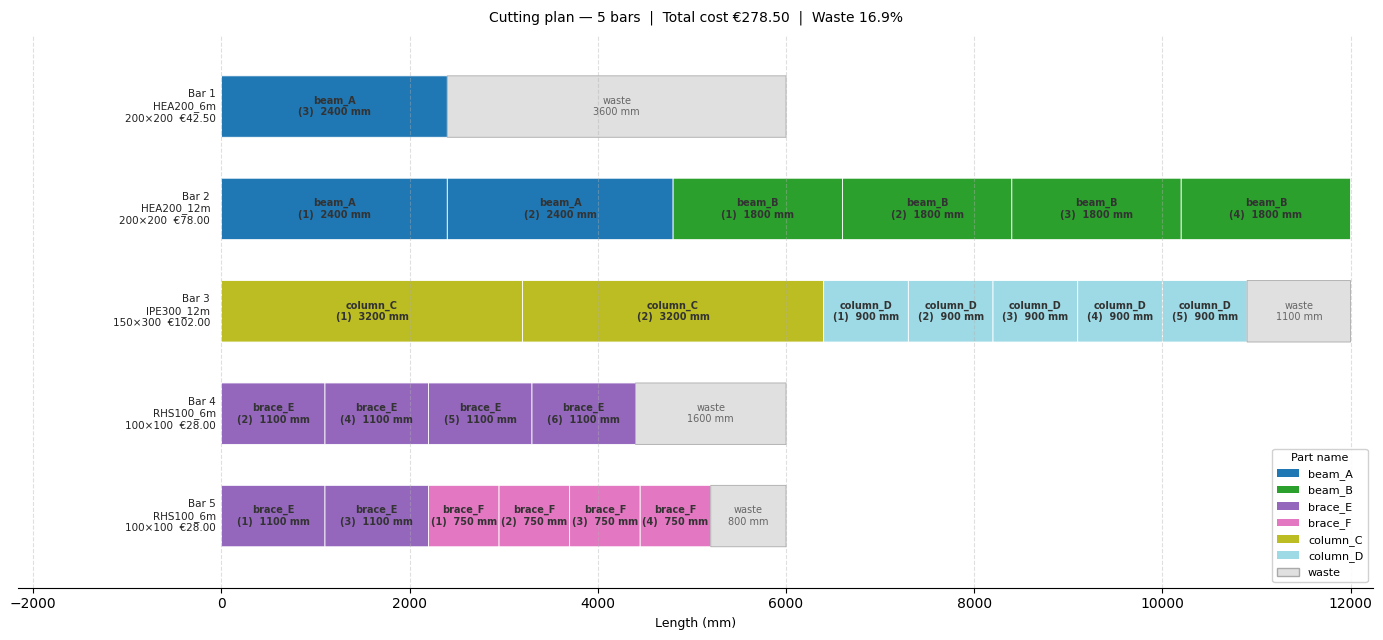

In [11]:
# ----- colour palette: one colour per unique part *name* -----
all_part_names = sorted(parts["name"].unique())
palette        = plt.colormaps["tab20"].resampled(len(all_part_names))
part_color     = {n: palette(i) for i, n in enumerate(all_part_names)}
WASTE_COLOR    = "#e0e0e0"

def draw_cutting_plan(results, title_prefix=""):
    n_bars  = len(results)
    bar_h   = 0.6          # height of each bar rectangle
    gap     = 0.4          # vertical gap between bars
    row_h   = bar_h + gap

    fig_h   = max(4, n_bars * row_h + 1.5)
    fig, ax = plt.subplots(figsize=(14, fig_h))

    for row_idx, b in enumerate(results):
        y_bot = (n_bars - 1 - row_idx) * row_h
        bar_len = b["length_mm"]
        x_cursor = 0

        # Draw each cut
        for piece_id, piece_name, piece_len in b["cuts"]:
            color = part_color[piece_name]
            rect  = mpatches.FancyBboxPatch(
                (x_cursor, y_bot), piece_len, bar_h,
                boxstyle="round,pad=0", linewidth=0.6,
                edgecolor="white", facecolor=color,
            )
            ax.add_patch(rect)
            # Label: part name + piece instance tag
            short_id = piece_id.split("_")[-1]            # just the counter
            label    = f"{piece_name}\n({short_id})  {piece_len} mm"
            ax.text(
                x_cursor + piece_len / 2, y_bot + bar_h / 2,
                label, ha="center", va="center",
                fontsize=7, color="white" if _is_dark(color) else "#333",
                fontweight="bold", clip_on=True,
            )
            x_cursor += piece_len

        # Waste remainder
        if b["waste_mm"] > 0:
            rect = mpatches.FancyBboxPatch(
                (x_cursor, y_bot), b["waste_mm"], bar_h,
                boxstyle="round,pad=0", linewidth=0.6,
                edgecolor="#aaa", facecolor=WASTE_COLOR,
            )
            ax.add_patch(rect)
            if b["waste_mm"] > 0.04 * bar_len:
                ax.text(
                    x_cursor + b["waste_mm"] / 2, y_bot + bar_h / 2,
                    f"waste\n{b['waste_mm']} mm", ha="center", va="center",
                    fontsize=7, color="#666",
                )

        # Y-axis label
        prof_str = f"{b['profile'][0]}×{b['profile'][1]}"
        ax.text(
            -bar_len * 0.01, y_bot + bar_h / 2,
            f"Bar {b['bar_no']}\n{b['stock_name']}\n{prof_str}  €{b['cost']:.2f}",
            ha="right", va="center", fontsize=7.5, color="#222",
        )

    # Legend for part names
    legend_patches = [
        mpatches.Patch(facecolor=part_color[n], label=n)
        for n in all_part_names
    ]
    legend_patches.append(mpatches.Patch(facecolor=WASTE_COLOR, edgecolor="#aaa", label="waste"))
    ax.legend(handles=legend_patches, loc="lower right", fontsize=8,
              framealpha=0.9, title="Part name", title_fontsize=8)

    max_len = max(b["length_mm"] for b in results)
    ax.set_xlim(-max_len * 0.18, max_len * 1.02)
    ax.set_ylim(-gap, n_bars * row_h)
    ax.set_xlabel("Length (mm)", fontsize=9)
    ax.set_title(
        f"{title_prefix}Cutting plan — {n_bars} bars  |  "
        f"Total cost €{sum(b['cost'] for b in results):.2f}  |  "
        f"Waste {100*sum(b['waste_mm'] for b in results)/sum(b['length_mm'] for b in results):.1f}%",
        fontsize=10, pad=10,
    )
    ax.set_yticks([])
    ax.spines[["top","right","left"]].set_visible(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


def _is_dark(rgba, threshold=0.35):
    r, g, b, *_ = rgba
    luminance = 0.299*r + 0.587*g + 0.114*b
    return luminance < threshold


# Draw overall plan
draw_cutting_plan(all_results)

## 7 — Per-Profile Breakdown


────────────────────────────────────────────────────────────
  Profile 200×200  —  2 bar(s)  €120.50
────────────────────────────────────────────────────────────


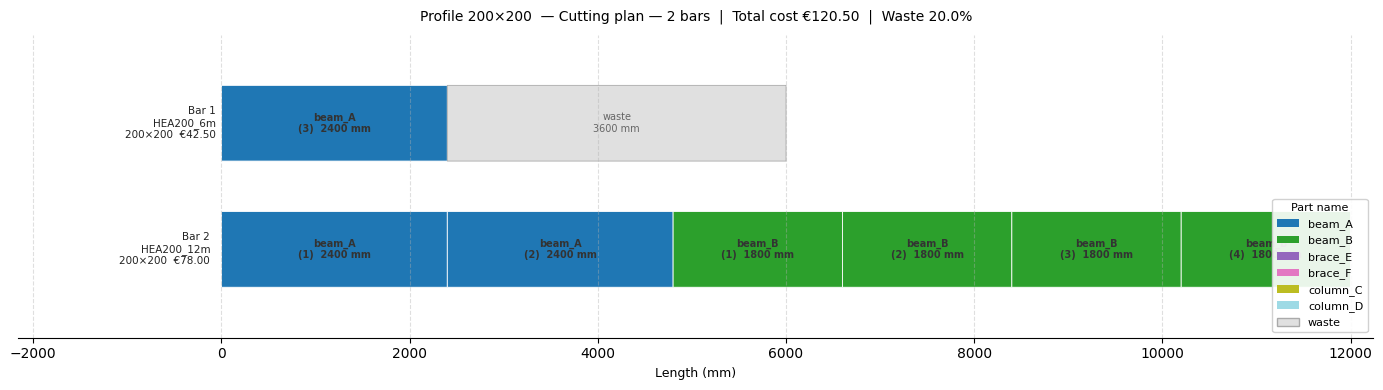


────────────────────────────────────────────────────────────
  Profile 150×300  —  1 bar(s)  €102.00
────────────────────────────────────────────────────────────


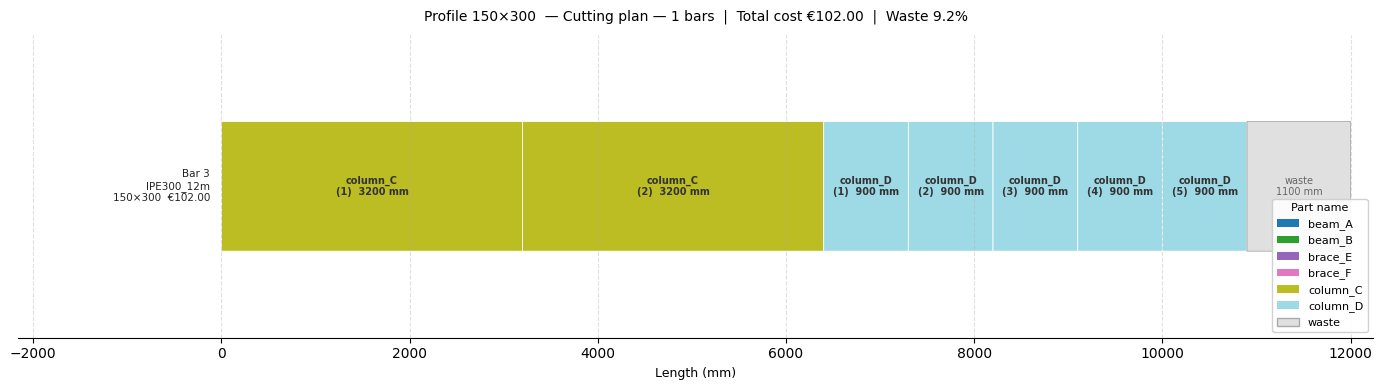


────────────────────────────────────────────────────────────
  Profile 100×100  —  2 bar(s)  €56.00
────────────────────────────────────────────────────────────


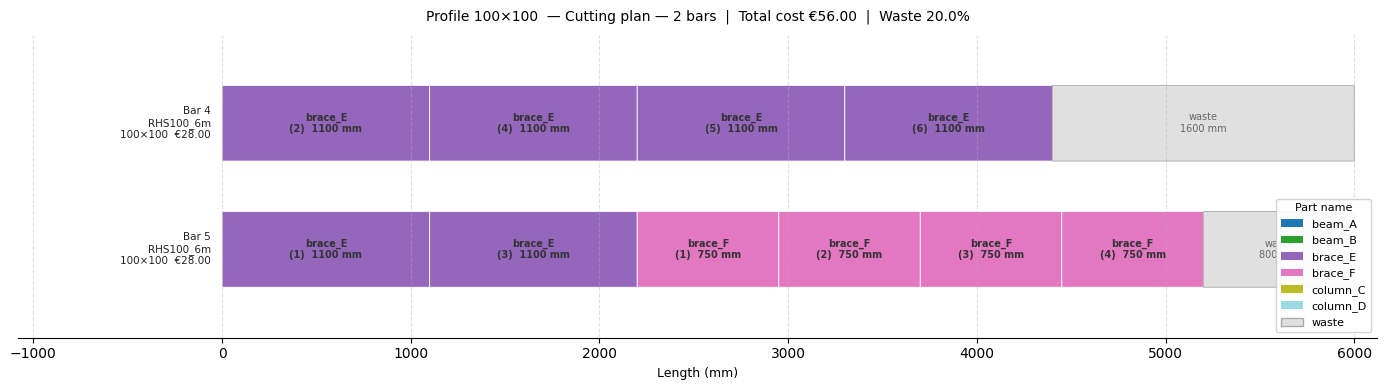

In [12]:
for prof in profiles:
    group_bars = [b for b in all_results if b["profile"] == prof]
    prof_str   = f"{prof[0]}×{prof[1]}"
    print(f"\n{'─'*60}")
    print(f"  Profile {prof_str}  —  {len(group_bars)} bar(s)  "
          f"€{sum(b['cost'] for b in group_bars):.2f}")
    print(f"{'─'*60}")
    draw_cutting_plan(group_bars, title_prefix=f"Profile {prof_str}  — ")